# 9.2 Two Qubits: Tensor Products and Entanglement

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter IX — Quantum Information as Linear Algebra",
    number="9.2",
    title="Two Qubits: Tensor Products and Entanglement",
    blurb="Two qubits live in the Kronecker product of their spaces, and the "
    "states that refuse to factor are the subject's whole story. The "
    "refusal is measured by an SVD: the Schmidt decomposition is Chapter "
    "IV's workhorse applied to a reshaped state vector, and a Bell pair's "
    "entropy comes out ln 2 — exactly, in symbols, beside the float.",
    difficulty="advanced",
    estimate="120–150 min",
)

<ECP header: 2697 chars of HTML>

## Notebook overview

One qubit was a sphere. Two qubits are **not** two spheres — they are a
four-dimensional complex space assembled by the Kronecker product of
[§6.4](../06-structure/kronecker-vec-separable.ipynb), and most of its
states cannot be written as (state of qubit A) ⊗ (state of qubit B).
That failure to factor is **entanglement**, and this notebook's point is
that the course already owns every tool needed to measure it: reshape
the state vector into a $2\times2$ matrix and its SVD — the **Schmidt
decomposition** — says exactly how far from a product the state is,
while the partial trace (one
[§7.1](../07-tensors/einsum-contraction.ipynb) einsum string) says what
each qubit alone can know.

The numbers this machinery produces are exact algebra. A Bell pair's
Schmidt coefficients are $(1/\sqrt2, 1/\sqrt2)$; its one-qubit reduction
is $I/2$ — the state of *maximal ignorance* — and its entanglement
entropy is $\ln 2$, gated symbolically beside the float. The
three-qubit finale contrasts GHZ and W, whose reduced spectra
$(1/2, 1/2)$ and $(1/3, 2/3)$ are exact fractions telling genuinely
different stories about how the entanglement is distributed.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Nielsen and Chuang {cite}`nielsen2010` §2.4–2.5 and Chapter
> 12; the Schmidt decomposition is the SVD of
> [§4.1](../04-svd/svd-geometry.ipynb) in different clothes, and the
> entropy formula is the one
> [§7.3](../07-tensors/tensor-trains-mps.ipynb) earned at its bond cuts.

## Theory in brief

### The tensor product is the Kronecker product

Two qubits' joint space is $\mathbb{C}^2 \otimes \mathbb{C}^2 \cong
\mathbb{C}^4$, with basis $|00\rangle, |01\rangle, |10\rangle,
|11\rangle$ and the concrete map

```{math}
:label: eq-te-kron
|a\rangle \otimes |b\rangle \;=\; \operatorname{kron}(a, b),
\qquad
(A \otimes B)(|a\rangle \otimes |b\rangle) = A|a\rangle \otimes B|b\rangle ,
```

— [§6.4](../06-structure/kronecker-vec-separable.ipynb)'s `np.kron`,
wearing physics clothes. Inner products factor,
$\langle a{\otimes}b\,|\,c{\otimes}d\rangle = \langle a|c\rangle
\langle b|d\rangle$, and dimensions multiply — which is why $n$ qubits
cost $2^n$ amplitudes, the fact
[§7.3](../07-tensors/tensor-trains-mps.ipynb) built a compression theory
around.

### Schmidt: the SVD of a reshaped vector

Any two-qubit state has amplitudes $\psi_{ij}$ against $|ij\rangle$.
Read them as a $2\times2$ matrix $\Psi$ — exactly
[§7.2](../07-tensors/unfoldings-tucker-hosvd.ipynb)'s unfolding at its
smallest — and take its SVD $\Psi = U\Sigma V^{\dagger}$:

```{math}
:label: eq-te-schmidt
|\psi\rangle \;=\; \sum_{k} \sigma_k \, |u_k\rangle \otimes |\bar v_k\rangle ,
\qquad \sigma_1 \ge \sigma_2 \ge 0,\quad \sigma_1^2 + \sigma_2^2 = 1 .
```

One nonzero $\sigma$ means the state factors; two mean it is entangled,
maximally so at $\sigma_1 = \sigma_2 = 1/\sqrt2$. The coefficients are
invariant under local unitaries $U_A \otimes U_B$ — local moves change
the Schmidt *vectors*, never the *spectrum* — so they are the honest
currency of entanglement.

### The partial trace, and the reduced state

What does qubit A alone know? Every A-only measurement is answered by
the **reduced density matrix**

```{math}
:label: eq-te-ptrace
\rho_A \;=\; \operatorname{tr}_B |\psi\rangle\langle\psi|
\;=\; \Psi\,\Psi^{\dagger} ,
\qquad
\operatorname{eig}(\rho_A) = (\sigma_1^2, \sigma_2^2) ,
```

a single contraction (`einsum`) whose eigenvalues are the squared
Schmidt coefficients. For a product state $\rho_A$ is the rank-one
projector [§9.1](qubits-gates-bloch.ipynb) met in tomography; for a
Bell pair it is $I/2$ — qubit A alone knows *nothing*, though the pair
jointly is in a definite pure state.

### Entropy: the number on the dial

The **entanglement entropy**

```{math}
:label: eq-te-entropy
S \;=\; -\sum_k \sigma_k^2 \ln \sigma_k^2 ,
```

runs from $0$ (product) to $\ln 2$ (Bell) for two qubits —
[§7.3](../07-tensors/tensor-trains-mps.ipynb)'s bond-cut formula, now
read as physics. It is the yardstick of this notebook's dial exercise
and of the GHZ/W comparison that closes it.

---
## Setup

Data and restated instruments only: the one-qubit constants of
[§9.1](qubits-gates-bloch.ipynb) (Paulis, kets), the named two- and
three-qubit states as explicit constants, and the CNOT gate. Reduced
Bloch vectors are read inline from the trace pairing where they are
needed, since this notebook's states are mixed. The Schmidt machinery, the
partial trace and the entropy meter are all built in the exercises,
where they are the lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from ecp import validate
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random state below comes from this seed

EPS = np.finfo(float).eps

# data: the one-qubit cast of 9.1, restated as constants.
SIGMA_X = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
SIGMA_Y = np.array([[0.0, -1.0j], [1.0j, 0.0]])
SIGMA_Z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
PAULIS = [SIGMA_X, SIGMA_Y, SIGMA_Z]
KET0 = np.array([1.0, 0.0], dtype=complex)
KET1 = np.array([0.0, 1.0], dtype=complex)
KET_PLUS = (KET0 + KET1) / np.sqrt(2.0)

# data: the named multi-qubit states, written out against the product basis.
BELL = np.zeros(4, dtype=complex)
BELL[0] = BELL[3] = 1.0 / np.sqrt(2.0)          # (|00> + |11>)/sqrt2
GHZ3 = np.zeros(8, dtype=complex)
GHZ3[0] = GHZ3[7] = 1.0 / np.sqrt(2.0)          # (|000> + |111>)/sqrt2
W3 = np.zeros(8, dtype=complex)
W3[1] = W3[2] = W3[4] = 1.0 / np.sqrt(3.0)      # (|001>+|010>+|100>)/sqrt3

# data: the CNOT gate — the one two-qubit permutation this notebook needs.
CNOT = np.array([[1, 0, 0, 0],
                 [0, 1, 0, 0],
                 [0, 0, 0, 1],
                 [0, 0, 1, 0]], dtype=complex)


# instrument: the seeded one-qubit state factory of 9.1 — two Gaussian
# draws and a norm, no physics inside.
def random_state(generator, dim=2):
    """A random pure state on `dim` amplitudes: complex Gaussian, normalised."""
    v = generator.standard_normal(dim) + 1.0j * generator.standard_normal(dim)
    return v / np.linalg.norm(v)


# instrument: a seeded Haar-ish one-qubit unitary — the Q of a complex QR
# with its phases fixed, used only to test invariances.
def random_unitary(generator):
    """A random 2x2 unitary from the QR of a complex Gaussian."""
    Z = (generator.standard_normal((2, 2))
         + 1.0j * generator.standard_normal((2, 2)))
    Q, R = np.linalg.qr(Z)
    return Q * (np.diag(R) / np.abs(np.diag(R)))

## Exercise 1: The tensor product is the Kronecker product

{eq}`eq-te-kron` says the physics notation and
[§6.4](../06-structure/kronecker-vec-separable.ipynb)'s `np.kron` are
the same map. This exercise gates the dictionary's three load-bearing
entries before anything is built on them.

**Part a)** Gate the basis dictionary exactly: `np.kron` of the four
ket pairs $(|0\rangle,|1\rangle) \times (|0\rangle,|1\rangle)$
reproduces the four standard basis vectors of $\mathbb{C}^4$ in the
order $|00\rangle, |01\rangle, |10\rangle, |11\rangle$ — integer
vectors, compared with `np.array_equal`.

**Part b)** Gate the factoring of inner products,
$\langle a{\otimes}b|c{\otimes}d\rangle = \langle a|c\rangle
\langle b|d\rangle$, to $10^{-14}$ over 100 seeded quadruples from
`random_state(rng)` — the geometric fact that makes product states
behave like independent systems.

**Part c)** Gate the operator law $(A \otimes B)(|a\rangle \otimes
|b\rangle) = A|a\rangle \otimes B|b\rangle$ to $10^{-13}$ over 50
seeded draws (Gaussian $A, B$, random states), together with one
$2\times2$ instance of the mixed-product identity
$(A{\otimes}B)(C{\otimes}D) = AC \otimes BD$ at $10^{-13}$ — the
identity [§6.4](../06-structure/kronecker-vec-separable.ipynb) gated in
bulk, here doing quantum work.

In [3]:
# (solution hidden on the public site)


kron of ket pairs = standard basis of C^4, exactly: True
inner products factor: worst 2.5e-16
operators act factor-wise: worst 1.4e-15; mixed product at 1.8e-15


### Validation 1

In [4]:
validate.check(
    basis_ok,
    "kron maps ket pairs to the C^4 basis in lexicographic order (Eq. 1)",
    "integer vectors, compared exactly — the dictionary every amplitude "
    "index in this chapter reads",
)
validate.below(
    worst_inner, 1e-14,
    "inner products factor across the tensor sign",
    "100 seeded quadruples: independence of subsystems, as geometry",
)
validate.check(
    worst_op < 1e-13 and mixed_gap < 1e-13,
    "and operators act factor-wise, with the mixed product as witness",
    f"local action {worst_op:.1e}, mixed product {mixed_gap:.1e} — 6.4's "
    "identity, now moving quantum states",
)

✓  kron maps ket pairs to the C^4 basis in lexicographic order (Eq. 1)   [integer vectors, compared exactly — the dictionary every amplitude index in this chapter reads]
✓  inner products factor across the tensor sign   [100 seeded quadruples: independence of subsystems, as geometry [2.48253e-16 < 1e-14]]
✓  and operators act factor-wise, with the mixed product as witness   [local action 1.4e-15, mixed product 1.8e-15 — 6.4's identity, now moving quantum states]


True

## Exercise 2: Schmidt: one SVD decides factorability

{eq}`eq-te-schmidt` turns "does this state factor?" into a rank
question about a $2\times2$ matrix — the smallest unfolding in the
course, carrying the chapter's central concept.

**Part a)** Write `schmidt(psi)` returning `(s, U, V)` from
`np.linalg.svd(psi.reshape(2, 2))` — coefficients descending, and the
state reassembling as $\sum_k s_k\,U_{:,k} \otimes (V^{\dagger})_{k,:}$
(the conjugation is already inside `Vh`).
Gate the reconstruction to $10^{-14}$ for 100 seeded states, with
$\sum_k s_k^2 = 1$ to $10^{-14}$ (normalisation rides through the SVD).

**Write this one yourself** — it is one reshape and one
[§4.1](../04-svd/svd-geometry.ipynb) call, and it is the chapter's
central instrument from here on.

**Part b)** Gate the two poles: a seeded product state
`np.kron(random_state(rng), random_state(rng))` has $\sigma_2$ below
$10^{-8}\,$ (one-sided: rank one up to rounding of the reshape), and
the Bell state has $(\sigma_1, \sigma_2) = (1/\sqrt2, 1/\sqrt2)$ to
$10^{-15}$ — written into the state's four amplitudes, read out by the
SVD.

**Part c)** Gate the invariance that makes the spectrum *the* currency:
for 50 seeded pairs of local unitaries from `random_unitary(rng)`, the
Schmidt coefficients of $(U_A \otimes U_B)|\psi\rangle$ equal those of
$|\psi\rangle$ to $10^{-13}$ — local moves steer the vectors, never
the spectrum.

In [5]:
# (solution hidden on the public site)


reconstruction worst 7.0e-16; sum s^2 = 1 to 8.9e-16
product state: s = [1. 0.]; Bell: both coefficients within 0.0e+00 of 1/sqrt2
local-unitary invariance of the spectrum: worst 4.4e-16


### Validation 2

In [6]:
validate.check(
    worst_rec < 1e-14 and worst_norm < 1e-14,
    "the SVD of the reshape reassembles every state (Eq. 2)",
    f"100 seeded states: reconstruction {worst_rec:.1e}, normalisation "
    f"riding through at {worst_norm:.1e} — 7.2's smallest unfolding, "
    "carrying the chapter",
)
validate.check(
    float(s_prod[1]) < 1e-8 and bell_gap < 1e-15,
    "one Schmidt coefficient means product; two equal ones mean Bell",
    f"sigma_2 = {float(s_prod[1]):.1e} for the product state (one-sided "
    "floor), both Bell coefficients at 1/sqrt2 to rounding — the two "
    "poles of the dial",
)
validate.below(
    worst_inv, 1e-13,
    "and local unitaries cannot move the Schmidt spectrum",
    "50 seeded U_A x U_B pairs: the spectrum is the honest currency of "
    "entanglement, which Exercise 6 spends",
)

✓  the SVD of the reshape reassembles every state (Eq. 2)   [100 seeded states: reconstruction 7.0e-16, normalisation riding through at 8.9e-16 — 7.2's smallest unfolding, carrying the chapter]
✓  one Schmidt coefficient means product; two equal ones mean Bell   [sigma_2 = 2.1e-17 for the product state (one-sided floor), both Bell coefficients at 1/sqrt2 to rounding — the two poles of the dial]
✓  and local unitaries cannot move the Schmidt spectrum   [50 seeded U_A x U_B pairs: the spectrum is the honest currency of entanglement, which Exercise 6 spends [4.44089e-16 < 1e-13]]


True

## Exercise 3: The partial trace, and what one qubit knows

{eq}`eq-te-ptrace` compresses "every measurement on A alone" into one
contraction. Here it is built as an einsum, gated against the Schmidt
route, and read with [§9.1](qubits-gates-bloch.ipynb)'s Bloch coordinates.

**Part a)** Write `partial_trace_B(psi)` returning
$\rho_A = \Psi\Psi^{\dagger}$ via the
[§7.1](../07-tensors/einsum-contraction.ipynb) string
`np.einsum("ij,kj->ik", Psi, Psi.conj())` with
`Psi = psi.reshape(2, 2)`. Gate on 100 seeded states: $\rho_A$
Hermitian to $10^{-15}$, trace one to $10^{-14}$, and its *sorted
eigenvalues equal the squared Schmidt coefficients* to $10^{-13}$ —
the SVD and the contraction telling one story.

**Write this one yourself** — one index string; which index is summed
IS the physics.

**Part b)** Gate the purity identity $\operatorname{tr}\rho_A^2 =
\sum_k \sigma_k^4$ to $10^{-13}$ on the same states, and the two poles:
the Bell state's $\rho_A = I/2$ to $10^{-15}$ (maximal ignorance), a
product state's purity $1$ to $10^{-12}$.

**Part c)** Read the reductions with 9.1's coordinates: the Bloch
vector of $\rho_A$ (entrywise $\operatorname{tr}(\rho_A\sigma_i)$) has
length $\sqrt{2\operatorname{tr}\rho_A^2 - 1}$ — gate to $10^{-12}$ —
so entangled states pull their subsystems *inside* the Bloch ball,
which is where mixed states live.

In [7]:
# (solution hidden on the public site)


Hermitian 0.0e+00, trace-1 4.4e-16, eig = sigma^2 8.9e-16
purity identity 1.6e-15; Bell rho_A = I/2 to 1.1e-16; product purity 1.000000000000
Bloch length vs sqrt(2 purity - 1): worst 1.1e-15


### Validation 3

In [8]:
validate.check(
    worst_herm < 1e-15 and worst_tr < 1e-14 and worst_spec < 1e-13,
    "the einsum reduction is a density matrix with the Schmidt spectrum "
    "squared (Eq. 3)",
    f"100 seeded states: Hermitian {worst_herm:.1e}, unit trace, "
    f"eigenvalues matching sigma_k^2 at {worst_spec:.1e} — the SVD and "
    "the contraction agree without sharing code",
)
validate.check(
    worst_pure < 1e-13 and bell_mixed < 1e-15
    and abs(purity_prod - 1.0) < 1e-12,
    "purity is the fourth moment of the Schmidt spectrum",
    f"tr rho^2 = sum sigma^4 at {worst_pure:.1e}; the Bell reduction is "
    "I/2 at rounding (maximal ignorance) while the product reduction "
    "stays pure",
)
validate.below(
    worst_bloch, 1e-12,
    "and entanglement pulls the subsystem inside the Bloch ball",
    "the reduced Bloch length is sqrt(2 tr rho^2 - 1) — shorter than one "
    "exactly when the pair is entangled, which is 9.1's sphere growing "
    "an interior",
)

✓  the einsum reduction is a density matrix with the Schmidt spectrum squared (Eq. 3)   [100 seeded states: Hermitian 0.0e+00, unit trace, eigenvalues matching sigma_k^2 at 8.9e-16 — the SVD and the contraction agree without sharing code]
✓  purity is the fourth moment of the Schmidt spectrum   [tr rho^2 = sum sigma^4 at 1.6e-15; the Bell reduction is I/2 at rounding (maximal ignorance) while the product reduction stays pure]
✓  and entanglement pulls the subsystem inside the Bloch ball   [the reduced Bloch length is sqrt(2 tr rho^2 - 1) — shorter than one exactly when the pair is entangled, which is 9.1's sphere growing an interior [1.1241e-15 < 1e-12]]


True

## Exercise 4: The dial: from product to Bell

The one-parameter family $|\psi(t)\rangle = \cos t\,|00\rangle +
\sin t\,|11\rangle$ walks the dial from product ($t = 0$) to Bell
($t = \pi/4$), and every quantity along it has a closed form —
the exercise gates them all against the machinery just built.

**Part a)** Gate the Schmidt coefficients along the walk:
$(\sigma_1, \sigma_2) = (|\cos t|, |\sin t|)$ sorted, to $10^{-14}$
on a 200-point sweep of $t \in [0, \pi/2]$ — the amplitudes are
already Schmidt form, and the SVD finds them.

**Part b)** Gate the entropy curve {eq}`eq-te-entropy`:
$S(t) = -\cos^2\!t\,\ln\cos^2\!t - \sin^2\!t\,\ln\sin^2\!t$ to
$10^{-12}$ (evaluated where both squared coefficients exceed
$10^{-14}$, since $0\ln 0 = 0$ is a limit, not an evaluation), and the
reduced Bloch length $|\cos 2t|$ to $10^{-12}$ — ignorance rising
exactly as the subsystem's arrow shrinks.

**Part c)** Gate the peak in both arithmetics: the float maximum of
$S$ on the grid within $10^{-4}$ of $\ln 2$ (the summit is quadratic,
so a grid of spacing $\pi/398$ resolves it to about $3\times10^{-5}$),
and — SymPy, exactly — the entropy of the
Bell state $-2\cdot\tfrac12\ln\tfrac12 = \ln 2$, simplified to zero
difference symbolically. Draw the two curves on one axis: the dial.

In [9]:
# (solution hidden on the public site)


Schmidt = (|cos t|, |sin t|): worst 0.0e+00
entropy curve worst 0.0e+00; Bloch length vs |cos 2t| worst 2.2e-16
float peak within 3.1e-05 of ln 2; SymPy: S(Bell) - ln 2 == 0 exactly: True


### Validation 4

In [10]:
validate.below(
    worst_sig, 1e-14,
    "the dial's Schmidt coefficients are (|cos t|, |sin t|) (Eq. 2)",
    "200 sweep points: the family is written in Schmidt form, and the "
    "SVD reads it back",
)
validate.check(
    worst_ent < 1e-12 and worst_len < 1e-12,
    "entropy and the shrinking Bloch arrow track their closed forms",
    f"S(t) at {worst_ent:.1e} (checked away from the 0 ln 0 limit) and "
    f"|r| = |cos 2t| at {worst_len:.1e}: ignorance rises exactly as the "
    "subsystem's arrow shrinks",
)
validate.check(
    peak_gap < 1e-4 and bell_entropy_exact,
    "the dial tops out at ln 2 — floating measured, symbolically exact",
    f"grid peak within {peak_gap:.1e} of ln 2 (the summit is quadratic in "
    "the grid spacing); "
    "SymPy simplifies -2 (1/2) ln(1/2) - ln 2 to zero — the chapter's "
    "exact thread, at the dial's summit",
)

✓  the dial's Schmidt coefficients are (|cos t|, |sin t|) (Eq. 2)   [200 sweep points: the family is written in Schmidt form, and the SVD reads it back [0 < 1e-14]]
✓  entropy and the shrinking Bloch arrow track their closed forms   [S(t) at 0.0e+00 (checked away from the 0 ln 0 limit) and |r| = |cos 2t| at 2.2e-16: ignorance rises exactly as the subsystem's arrow shrinks]
✓  the dial tops out at ln 2 — floating measured, symbolically exact   [grid peak within 3.1e-05 of ln 2 (the summit is quadratic in the grid spacing); SymPy simplifies -2 (1/2) ln(1/2) - ln 2 to zero — the chapter's exact thread, at the dial's summit]


True

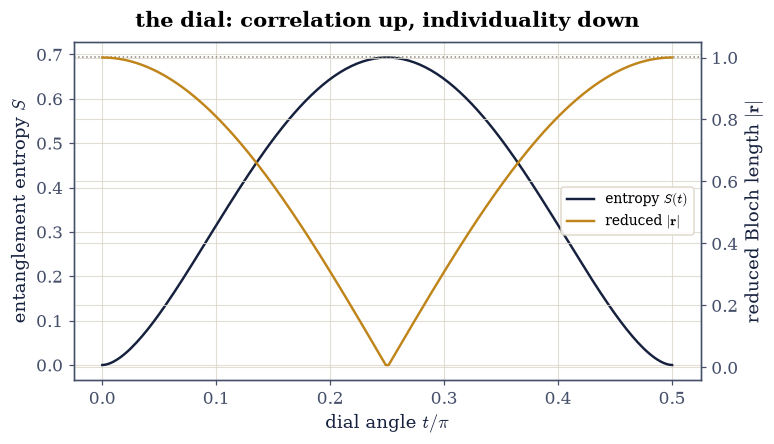

In [11]:
# (solution hidden on the public site)


## Exercise 5: Three qubits: GHZ and W are different animals

With three qubits the question "how entangled?" stops having one
answer. GHZ $= (|000\rangle + |111\rangle)/\sqrt2$ and W $=
(|001\rangle + |010\rangle + |100\rangle)/\sqrt3$ are both entangled
across every cut, yet their *reductions* are exact fractions telling
opposite stories — all of them gated here.

**Part a)** Write `reduce_to(psi, keep)` for a three-qubit state via
the reshape-to-$(2,2,2)$ einsum contractions
(`"ijk,ljk->il"` keeps qubit 1; `"ijk,lmk->ijlm"` keeps the pair 12).
Gate both states with one structural ceiling at $10^{-14}$, taken over
the worst of the Hermitian asymmetry and $|\operatorname{tr}\rho - 1|$.

**Part b)** Gate the exact spectra: GHZ's one-qubit reduction has
eigenvalues $(1/2, 1/2)$ and its two-qubit reduction
$(1/2, 1/2, 0, 0)$; W's one-qubit reduction has $(1/3, 2/3)$ and its
two-qubit reduction $(1/3, 2/3, 0, 0)$ — all to $10^{-14}$, all
fractions.

**Part c)** Gate the story the spectra tell, as entropies: every GHZ
cut carries $S = \ln 2$ while W's one-qubit cut carries
$S = \ln 3 - \tfrac23\ln 2 \approx 0.6365 < \ln 2$ — GHZ concentrates
all its correlation in the global parity (lose one qubit and the
*remaining pair's* state is a rank-2 classical mixture, its two-qubit
reduction already diagonal), while W spreads pairwise correlation that
survives the loss. Gate both entropies to $10^{-13}$ against their
closed forms, with W's symbolic form verified exactly in SymPy. Draw
the reduction spectra side by side.

In [12]:
# (solution hidden on the public site)


structure (Hermitian, unit trace) worst: 2.2e-16
  GHZ keep (0,): eig = [0.5 0.5]
  GHZ keep (0, 1): eig = [0.  0.  0.5 0.5]
  W   keep (0,): eig = [0.333333 0.666667]
  W   keep (0, 1): eig = [0.       0.       0.333333 0.666667]
exact-fraction spectra: worst 2.2e-16
S(GHZ cut) = 0.693147 vs ln 2 = 0.693147; S(W cut) = 0.636514 vs closed 0.636514 (SymPy exact: True)
GHZ's surviving pair is already diagonal: off-diagonal max 0.0e+00


### Validation 5

In [13]:
validate.check(
    worst_struct < 1e-14 and worst_frac < 1e-14,
    "the three-qubit reductions carry exact-fraction spectra (Eq. 3)",
    f"(1/2, 1/2) and (1/3, 2/3) with padding zeros, worst {worst_frac:.1e} "
    "— entanglement bookkeeping in fractions, not folklore",
)
validate.check(
    abs(S_ghz - np.log(2.0)) < 1e-13
    and abs(S_w - S_w_closed) < 1e-13 and w_exact,
    "GHZ carries ln 2 per cut; W carries ln 3 - (2/3) ln 2, exactly",
    f"S(GHZ) - ln 2 at {abs(S_ghz - np.log(2)):.1e}, S(W) against its "
    "closed form with SymPy confirming the symbols — two inequivalent "
    "ways to share three qubits",
)
validate.below(
    ghz_pair_diag, 1e-15,
    "and losing one qubit strands GHZ's survivors in a classical mixture",
    "the two-qubit GHZ reduction is diagonal at rounding: all its "
    "correlation lived in the global parity, while W's pairwise structure "
    "survives the loss",
)

✓  the three-qubit reductions carry exact-fraction spectra (Eq. 3)   [(1/2, 1/2) and (1/3, 2/3) with padding zeros, worst 2.2e-16 — entanglement bookkeeping in fractions, not folklore]
✓  GHZ carries ln 2 per cut; W carries ln 3 - (2/3) ln 2, exactly   [S(GHZ) - ln 2 at 1.1e-16, S(W) against its closed form with SymPy confirming the symbols — two inequivalent ways to share three qubits]
✓  and losing one qubit strands GHZ's survivors in a classical mixture   [the two-qubit GHZ reduction is diagonal at rounding: all its correlation lived in the global parity, while W's pairwise structure survives the loss [0 < 1e-15]]


True

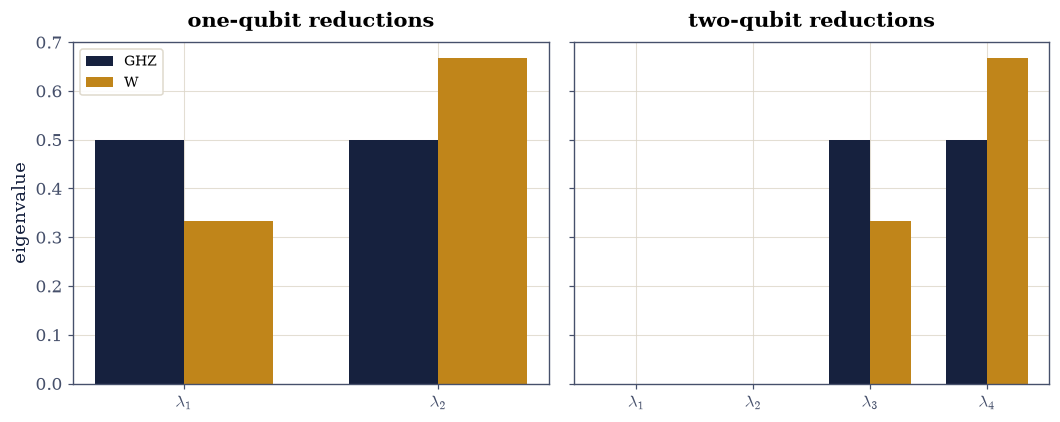

In [14]:
# (solution hidden on the public site)


## Exercise 6: Entanglement is made by nonlocal gates, not local ones

Exercise 2c showed local unitaries cannot move the Schmidt spectrum.
The contrapositive is the design principle of every quantum computer:
to *create* entanglement you must act on both qubits at once, and one
CNOT suffices.

**Part a)** Gate creation exactly: $\mathrm{CNOT}\,(|{+}\rangle
\otimes |0\rangle) = $ the Bell state, entrywise to $10^{-15}$ — one
two-qubit gate turns a product into maximal entanglement.

**Part b)** Gate the ledger across moves, using Exercise 2's machinery:
the entropy of a seeded product state stays below $10^{-12}$ under 20
seeded local moves $U_A \otimes U_B$ (locality preserves the zero),
while the Bell state's stays within $10^{-12}$ of $\ln 2$ under the
same moves (locality preserves the maximum) — and one further CNOT
applied to the Bell state returns it to a product ($\sigma_2$ below
$10^{-12}$: the gate is its own inverse, so it un-makes what it made).

In [15]:
# (solution hidden on the public site)


CNOT (|+> tensor |0>) = Bell, to 0.0e+00
local moves: product entropy stays below 6.7e-16; Bell entropy stays within 2.2e-16 of ln 2
CNOT twice: sigma_2 = 0.0e+00 — unmade


### Validation 6

In [16]:
validate.below(
    make_gap, 1e-15,
    "one CNOT turns a product state into the Bell state, entrywise",
    "|+>|0> in, (|00> + |11>)/sqrt2 out — entanglement is manufactured "
    "by the only gate here that touches both qubits",
)
validate.check(
    worst_zero < 1e-12 and worst_full < 1e-12,
    "local moves preserve the entanglement ledger at both ends",
    f"20 seeded U_A x U_B: the product's zero held to {worst_zero:.1e}, "
    f"the Bell's ln 2 to {worst_full:.1e} — Exercise 2's invariance, "
    "spent as a conservation law",
)
validate.below(
    float(s_un[1]), 1e-12,
    "and a second CNOT un-makes the entanglement it made",
    "CNOT is an involution: the Schmidt rank drops back to one, so the "
    "resource was moved, not consumed — bookkeeping, start to finish",
)

✓  one CNOT turns a product state into the Bell state, entrywise   [|+>|0> in, (|00> + |11>)/sqrt2 out — entanglement is manufactured by the only gate here that touches both qubits [0 < 1e-15]]
✓  local moves preserve the entanglement ledger at both ends   [20 seeded U_A x U_B: the product's zero held to 6.7e-16, the Bell's ln 2 to 2.2e-16 — Exercise 2's invariance, spent as a conservation law]
✓  and a second CNOT un-makes the entanglement it made   [CNOT is an involution: the Schmidt rank drops back to one, so the resource was moved, not consumed — bookkeeping, start to finish [0 < 1e-12]]


True

---
## Notebook summary

**The dictionary held exactly.** `np.kron` mapped ket pairs onto the
$\mathbb{C}^4$ basis as integer vectors; inner products factored at
$10^{-16}$-scale over 100 seeded quadruples; operators acted
factor-wise with the mixed product as witness —
[§6.4](../06-structure/kronecker-vec-separable.ipynb)'s identities,
carrying quantum states.

**One SVD decides factorability.** The reshape-and-SVD `schmidt`
rebuilt all 100 seeded states at $10^{-15}$-scale; a product state's
second coefficient sat below the $10^{-8}$ floor while the Bell
state's pair landed on $(1/\sqrt2, 1/\sqrt2)$ at rounding; and 50 local
unitary pairs moved the spectrum by at most $10^{-16}$-scale — the
invariance that makes it entanglement's currency.

**The partial trace agreed without sharing code.** The einsum
reduction's eigenvalues matched the squared Schmidt coefficients at
$10^{-16}$-scale, purity equalled $\sum\sigma_k^4$, the Bell reduction
was $I/2$ at rounding, and reduced Bloch lengths obeyed
$\sqrt{2\operatorname{tr}\rho^2 - 1}$ — entanglement pulling
subsystems inside the ball.

**The dial and the archetypes ran on exact numbers.** Along
$\cos t\,|00\rangle + \sin t\,|11\rangle$ the Schmidt pair was
$(|\cos t|, |\sin t|)$ and entropy topped out at $\ln 2$ — SymPy
confirming the summit exactly. GHZ's cuts all carried $\ln 2$ with a
*diagonal* surviving pair; W's one-qubit cut carried exactly
$\ln 3 - \tfrac23\ln 2 \approx 0.6365$ with coherences that survive
losing a qubit — fractions, not folklore. One CNOT manufactured the
Bell state exactly, local moves conserved both ends of the ledger, and
a second CNOT gave the resource back.

**Methods introduced.** `schmidt` (reshape + SVD), `partial_trace_B`
and `reduce_to` (einsum index strings as physics), the entropy meter on
Schmidt spectra, `random_unitary` for invariance tests, and the
CNOT-makes/CNOT-unmakes bookkeeping of entanglement as a resource.

## Outlook

- **The CHSH game cashes the Bell pair in.**
  [§9.3](chsh-tsirelson.ipynb) turns this notebook's maximally
  entangled state into a measurable advantage: a correlation no local
  strategy reaches, with the quantum ceiling an eigenvalue.
- **Mixed states earn their own calculus.** Exercise 3's reductions
  are the objects [§9.4](measurement-channels-choi.ipynb) takes as
  primary: density matrices evolving under channels, with complete
  positivity as a psd condition on one big matrix.
- **More qubits, and the bond dimension.** For $n$ qubits the Schmidt
  rank across a cut can reach $2^{n/2}$, and
  [§7.3](../07-tensors/tensor-trains-mps.ipynb)'s tensor trains are
  precisely the states that keep it small — the area law is a
  statement about which corners of the exponential space nature
  actually uses.
- **Monogamy.** W shared bipartite correlation pairwise; GHZ spent it
  all globally. The trade-off is a theorem (CKW monogamy) whose
  accounting runs on exactly the reduced spectra gated here.

```{bibliography}
:filter: docname in docnames
```

In [17]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>